# Quantum Machine Learning Model for Conspicuity Detection in Production: QNN

We use a real-world weld inspection dataset to build a quantum-enhanced image classifier for conspicuity (defect) detection in production. In this notebook, we focus on a **quanvolutional neural network (QNN)** and compare it directly against a **classical convolutional neural network (CNN)** using the same weld images and the same classifier architecture.

The data subset and directory structure are prepared in Task 5.1, so we can concentrate here on quantum preprocessing, model design, training, and evaluation.

## Environment Preparation

We need to install PennyLane if it is not installed yet. Then, we import necessary libraries for this task.

In [1]:
# %pip install pennylane # uncommment this to install

In [2]:
# import libraries
import os
from PIL import Image

import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## Setting Hyperparameters and Paths

We define the key hyperparameters and paths that control our experiments. We specify the project data root and a separate folder for cached quanvolved images so that we do not recompute the quantum preprocessing every time.

We choose:

- **$28 \times 28$ pixels** as a compact image size,
- **6 classes** from the dataset,
- **4 qubits for each $2 \times 2$ patch**,
- **1 random quantum layer**,
- a moderate batch size, and
- 30 epochs

to balance training time with model convergence.

In [3]:
data_root = "conspicuity_production_data"               # root folder for prepared images
SAVE_PATH = "quanvolution/conspicuity_production_data"  # folder to save/load quanvolved data
PREPROCESS = True                                       # if True, recompute and save quantum features

img_size = (28, 28)           # target image size (height, width)
classes = [0, 1, 2, 3, 4, 5]  # six weld-defect classes
num_classes = len(classes)    # number of output classes
n_qubits = 4                  # number of qubits / quantum output channels
n_layers = 1                  # number of random quantum layers
BATCH_SIZE = 16               # training batch size
EPOCHS = 30                   # number of training epochs

np.random.seed(0)             # seed NumPy for reproducibility

## Loading Dataset

We load the pre-selected weld images from the project data folder created in Task 5.1.

For each split and class, we
- read the image files,
- convert them to a single grayscale channel,
- resize them to $28 \times 28$ pixels, and
- normalize pixel values to the range $[0, 1]$.

We then stack all processed images into NumPy arrays with an explicit channel dimension so that they are ready to be passed into both CNN and QNN models.

In [4]:
def load_split(split):
    X = []
    y = []
    split_dir = os.path.join(data_root, split)  # folder for train or test dataset
    
    for label in classes:
        class_dir = os.path.join(split_dir, str(label))  # folder for a particular class label
        if not os.path.isdir(class_dir):
            continue

        # iterate with a progress bar
        for fname in tqdm(os.listdir(class_dir), desc=f"{split} label {label}"):
            
            # skip non-image files
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue

            # get the path of each image
            path = os.path.join(class_dir, fname)
            img = Image.open(path)

            # grayscale conversion
            img = img.convert("L")

            # resize to the target resolution
            img = img.resize(img_size)

            # normalize pixel values within 0 and 1
            arr = np.array(img, dtype=np.float32) / 255.0
            X.append(arr)
            y.append(label)

    # add a channel dimension so images have shape (N, H, W, 1)
    X = np.array(X)[..., np.newaxis]  # number of images, height, width, 1 grayscale channel
    y = np.array(y, dtype=np.int64)   # integer class labels
    return X, y

In [5]:
X_train, y_train = load_split("train")
X_test, y_test = load_split("test")

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

test label 5: 100%|███████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 139.86it/s]

Train: (1356, 28, 28, 1) (1356,)
Test : (351, 28, 28, 1) (351,)


## Quantum Circuit

We define a small quantum circuit that processes one $2 \times 2$ image patch at a time using the following steps:

- We create a default device with **4 qubits**, initialized in the ground state.
- We **apply an RY rotation, aka the $R_y$ operation, on each qubit** to encode **4 classical inputs** (4 pixel values from the $2 \times 2$ patch).
- We apply a random quantum layer with `n_layers`, using parameters that are shared across all patches.
- We **measure 4 expectation values** in the computational basis using **the Pauli-Z observable** on each qubit.

Each of the **4 expectation values** lies in the range $[−1, 1]$ because it is a weighted average of possible measurement outcomes. These values **act as 4 quantum feature channels** for the downstream classifier.

In [6]:
dev = qml.device("default.qubit", wires=n_qubits)

# random layer parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, n_qubits))

@qml.qnode(dev)
def circuit(phi):
    # encode 4 classical values into 4 qubits
    for j in range(n_qubits):
        qml.RY(np.pi * phi[j], wires=j)
    
    # random trainable layer
    RandomLayers(rand_params, wires=list(range(n_qubits)))
    
    # measure 4 expectation values
    return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

## Quanvolution Scheme

We divide each $28 \times 28$ grayscale image into small $2\times 2$ patches to halve the spatial resolution. This is equivalent to using a 
$2\times 2$ *kernel* and a *stride* of 2 for a classical CNN. Unlike a classical convolution, however, each $2\times 2$ patch is processed by the quantum circuit: the 4 pixel values are encoded into 4 qubits, the circuit is applied, and the 4 resulting expectation values are stored as 4 channels in the corresponding output pixel. This produces a quanvolved image whose quantum transformation provides richer local features for the classifier.

In [7]:
def quanv(image):
    """Convolves the input image with many applications of the same quantum circuit."""
    H, W, _ = image.shape  # height, width, channels: 28 x 28 x 1
    out_H, out_W = H // 2, W // 2  # output spatial size after using 2x2 patches with stride 2
    out = np.zeros((out_H, out_W, n_qubits))  # one quantum feature vector (length = n_qubits) per output pixel

    # iterate over non-overlapping 2x2 patches of the input image
    for j in range(0, H, 2):
        for k in range(0, W, 2):
            # extract the 2x2 patch as a list of 4 scalar pixel values
            patch = [
                image[j,     k,     0],
                image[j,     k + 1, 0],
                image[j + 1, k,     0],
                image[j + 1, k + 1, 0],
            ]
            # run the quantum circuit on this patch to get 4 expectation values
            q_results = circuit(patch)

            # store the quantum outputs in the corresponding output pixel and channel
            for c in range(n_qubits):
                out[j // 2, k // 2, c] = q_results[c]
    return out

## Quantum Preprocessing

We apply the quanvolution operation to every training and test image to create quantum-preprocessed versions of the dataset. Without this step, the implementation would be a purely classical CNN instead of a QNN.

Because quanvolution is computationally more expensive than a classical convolution, we perform it once and save the resulting arrays to disk. On subsequent runs, we reload these cached quanvolved images instead of recomputing them by setting `PREPROCESS = False` in the cell above, which significantly speeds up our experiments.

In [8]:
if PREPROCESS:
    # quanvolve train images with progress bar
    q_X_train = np.array([quanv(img) for img in tqdm(X_train, desc="Quanvolving train images")])
    q_X_test  = np.array([quanv(img) for img in tqdm(X_test,  desc="Quanvolving test images")])
    
    os.makedirs(SAVE_PATH, exist_ok=True)

    # save pre-processed images
    np.save(os.path.join(SAVE_PATH, "conspicuity_q_train_images.npy"), q_X_train)
    np.save(os.path.join(SAVE_PATH, "conspicuity_q_test_images.npy"),  q_X_test)

Quanvolving test images: 100%|███████████████████████████████████████████████████████| 351/351 [35:55<00:00,  6.14s/it]


In [9]:
# load pre-processed images
q_X_train = np.load(os.path.join(SAVE_PATH, "conspicuity_q_train_images.npy"))
q_X_test  = np.load(os.path.join(SAVE_PATH, "conspicuity_q_test_images.npy"))

print("q_train_images:", q_X_train.shape)
print("q_test_images :", q_X_test.shape)

q_train_images: (1356, 14, 14, 4)
q_test_images : (351, 14, 14, 4)


## Visualizing Quanvolved Feature Maps

After quanvolution, each image is processed in 4 different ways, yielding 4 output channels (one per qubit).

We visualize a few example images alongside their corresponding quanvolved outputs by showing the original grayscale input and the 4 quantum output channels produced by the circuit. This allows us to see how the quantum layer transforms local weld patterns into different feature maps that the classifier can use to distinguish between defect types.

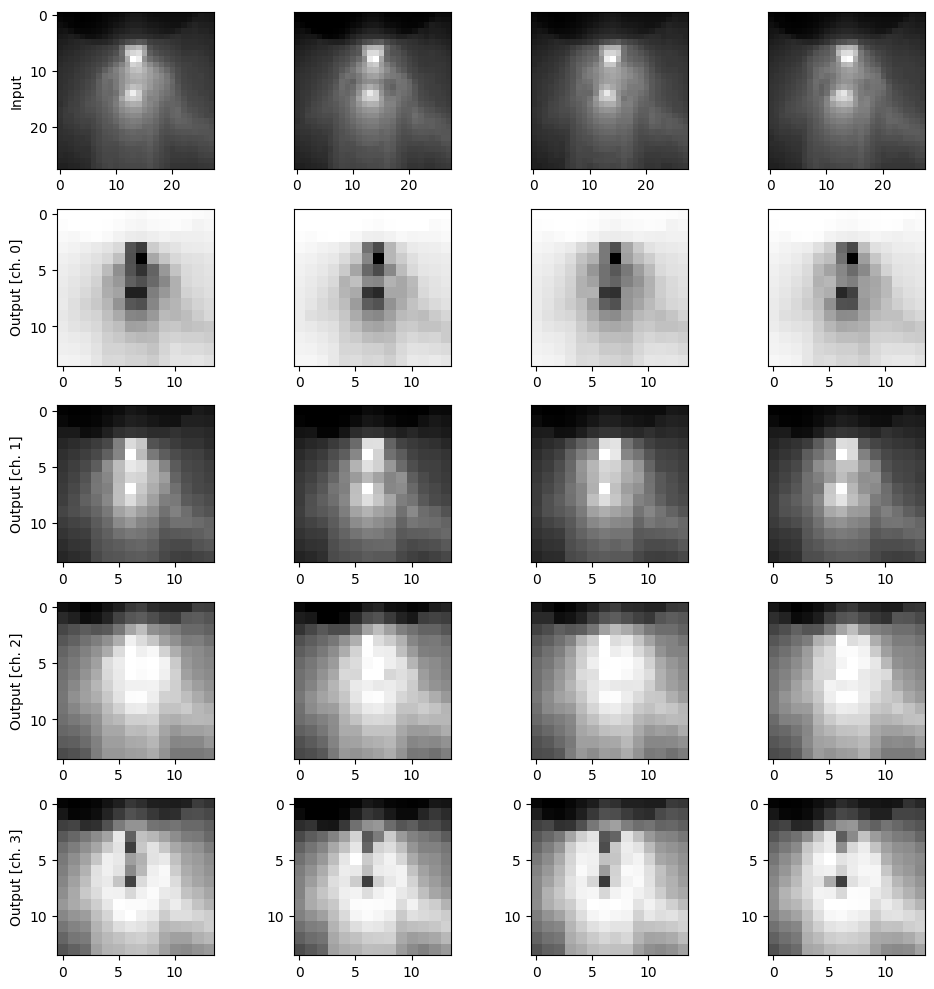

In [10]:
n_samples = 4

fig, axes = plt.subplots(1 + n_qubits, n_samples, figsize=(10, 10))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(X_train[k, :, :, 0], cmap="gray")

    # plot all output channels
    for c in range(n_qubits):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_X_train[k, :, :, c], cmap="gray")

plt.tight_layout()
plt.show()

## Shared Image Classifier for CNN and QNN

We define a small CNN-style classifier that can be applied to either raw or quanvolved images by changing only the input shape.
- If we use quantum pre-processed data, it will be QNN.
- If we do not use quantum pre-processed data, it will be CNN.

The architecture uses two convolution–pooling blocks followed by a dense layer and a final `softmax` layer over six classes. By keeping exactly the same classical head for both CNN and QNN, we ensure that any performance differences reflect the presence or absence of the quantum preprocessing step, not a change in model capacity.

We choose the `adam` optimizer because it is a widely used, adaptive gradient method that typically converges reliably with minimal tuning. We use `sparse_categorical_crossentropy` as the loss function, together with `accuracy` as the metric, because we are performing multi-class classification with integer class labels (0–5) rather than one-hot encoded targets.

In [11]:
def ImgClassifier(input_shape, num_classes=6):
    """builds a small cnn-style custom Keras model as classifier ready to be trained for given input shape."""
    model = keras.models.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(16, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## Training QNN Model

We train the classifier on the quanvolved images `q_X_train` and validate on `q_X_test` while keeping the same optimizer, loss, and training schedule as in the classical baseline.

In [12]:
# use QNN data
qnn_input_shape = q_X_train.shape[1:]  # (14, 14, 4) after quanv

# build model
qnn_model = ImgClassifier(qnn_input_shape, num_classes=6)

# train model
qnn_history = qnn_model.fit(q_X_train, y_train,
                            validation_data=(q_X_test, y_test),
                            epochs=EPOCHS,
                            batch_size=BATCH_SIZE,
                            verbose=2
                           )

Epoch 1/30
85/85 - 2s - 18ms/step - accuracy: 0.4956 - loss: 1.4525 - val_accuracy: 0.6809 - val_loss: 0.9978
Epoch 2/30
85/85 - 0s - 4ms/step - accuracy: 0.7906 - loss: 0.6760 - val_accuracy: 0.8091 - val_loss: 0.5773
Epoch 3/30
85/85 - 0s - 4ms/step - accuracy: 0.8400 - loss: 0.4506 - val_accuracy: 0.8746 - val_loss: 0.4038
Epoch 4/30
85/85 - 0s - 4ms/step - accuracy: 0.8776 - loss: 0.3243 - val_accuracy: 0.9031 - val_loss: 0.3281
Epoch 5/30
85/85 - 0s - 5ms/step - accuracy: 0.9130 - loss: 0.2568 - val_accuracy: 0.9031 - val_loss: 0.3108
Epoch 6/30
85/85 - 0s - 5ms/step - accuracy: 0.9388 - loss: 0.2115 - val_accuracy: 0.9145 - val_loss: 0.3271
Epoch 7/30
85/85 - 0s - 5ms/step - accuracy: 0.9181 - loss: 0.2119 - val_accuracy: 0.9174 - val_loss: 0.2840
Epoch 8/30
85/85 - 0s - 4ms/step - accuracy: 0.9528 - loss: 0.1572 - val_accuracy: 0.9288 - val_loss: 0.2125
Epoch 9/30
85/85 - 0s - 3ms/step - accuracy: 0.9572 - loss: 0.1422 - val_accuracy: 0.9231 - val_loss: 0.2174
Epoch 10/30
85/85 

## Training CNN Model

We train an identical classifier architecture on the raw grayscale images `X_train` and `X_test` without any quantum preprocessing. Because the only difference from the QNN setup is the input representation, this model serves as a direct classical baseline.

In [13]:
# use CNN data
cnn_input_shape = X_train.shape[1:]  # (28, 28, 1)

# build model
cnn_model = ImgClassifier(cnn_input_shape, num_classes=6)

# train model
cnn_history = cnn_model.fit(X_train, y_train,
                            validation_data=(X_test, y_test),
                            epochs=EPOCHS,
                            batch_size=BATCH_SIZE,
                            verbose=2
                           )

Epoch 1/30
85/85 - 2s - 24ms/step - accuracy: 0.4277 - loss: 1.5062 - val_accuracy: 0.7037 - val_loss: 1.0436
Epoch 2/30
85/85 - 0s - 5ms/step - accuracy: 0.7758 - loss: 0.7098 - val_accuracy: 0.7692 - val_loss: 0.6205
Epoch 3/30
85/85 - 1s - 6ms/step - accuracy: 0.8223 - loss: 0.5226 - val_accuracy: 0.8205 - val_loss: 0.4823
Epoch 4/30
85/85 - 0s - 5ms/step - accuracy: 0.8400 - loss: 0.4276 - val_accuracy: 0.7892 - val_loss: 0.5416
Epoch 5/30
85/85 - 1s - 8ms/step - accuracy: 0.8591 - loss: 0.3819 - val_accuracy: 0.8689 - val_loss: 0.3863
Epoch 6/30
85/85 - 1s - 6ms/step - accuracy: 0.8857 - loss: 0.3182 - val_accuracy: 0.8632 - val_loss: 0.3899
Epoch 7/30
85/85 - 0s - 4ms/step - accuracy: 0.8916 - loss: 0.2921 - val_accuracy: 0.9031 - val_loss: 0.3183
Epoch 8/30
85/85 - 0s - 4ms/step - accuracy: 0.9093 - loss: 0.2602 - val_accuracy: 0.8832 - val_loss: 0.3454
Epoch 9/30
85/85 - 0s - 4ms/step - accuracy: 0.9248 - loss: 0.2219 - val_accuracy: 0.8946 - val_loss: 0.2947
Epoch 10/30
85/85 

## Plotting

We plot the validation accuracy and validation loss curves for the CNN and QNN side by side across training epochs. These plots show whether one model converges faster, reaches higher accuracy, or attains lower loss on the held-out weld images. Visual comparison of the curves provides an intuitive summary of how similarly or differently the two models behave during training.

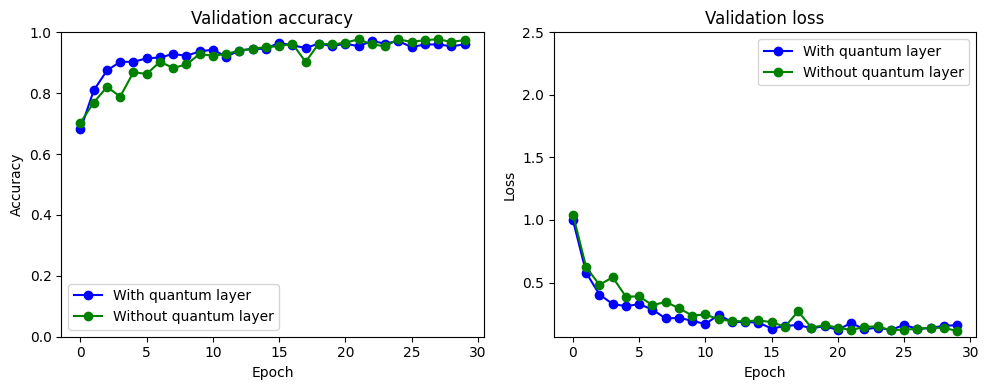

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# validation accuracy
ax1.plot(qnn_history.history["val_accuracy"], "-ob", label="With quantum layer")
ax1.plot(cnn_history.history["val_accuracy"], "-og", label="Without quantum layer")
ax1.set_title("Validation accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_ylim([0, 1])
ax1.legend()

# validation loss
ax2.plot(qnn_history.history["val_loss"], "-ob", label="With quantum layer")
ax2.plot(cnn_history.history["val_loss"], "-og", label="Without quantum layer")
ax2.set_title("Validation loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_ylim(top=2.5)
ax2.legend()

plt.tight_layout()
plt.show()

## Confusion Matrix

In [15]:
# helper: plot confusion matrix
def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel("predicted label")
    plt.ylabel("true label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


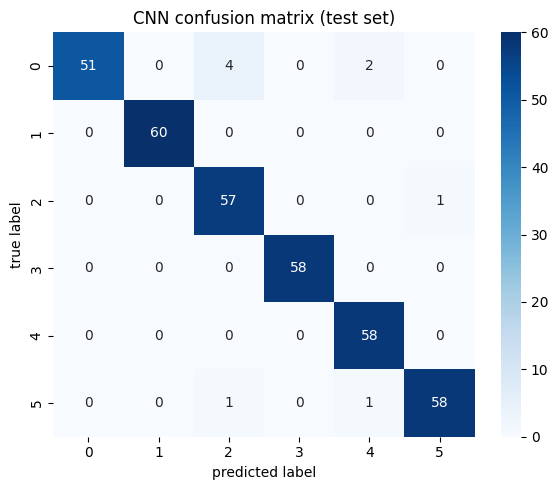

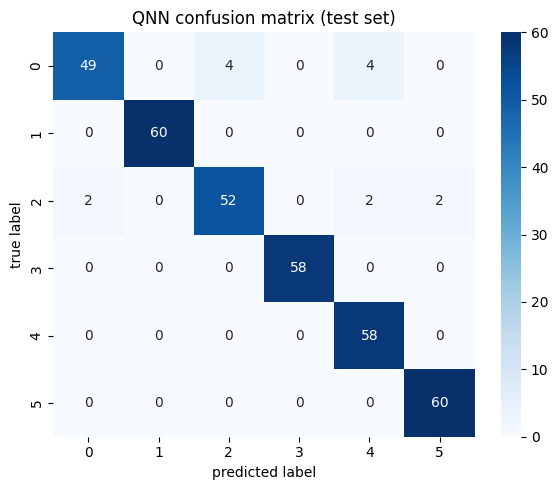

In [16]:
# make predictions on test set
y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)
y_pred_qnn = np.argmax(qnn_model.predict(q_X_test), axis=1)

# get confusion matrices (rows: true, cols: predicted)
cm_cnn = confusion_matrix(y_test, y_pred_cnn, labels=classes)
cm_qnn = confusion_matrix(y_test, y_pred_qnn, labels=classes)

# plot confusion matrices
plot_confusion_matrix(cm_cnn, classes, "CNN confusion matrix (test set)")
plot_confusion_matrix(cm_qnn, classes, "QNN confusion matrix (test set)")

In [17]:
# get per-class accuracy
per_class_acc_cnn = cm_cnn.diagonal() / cm_cnn.sum(axis=1)
per_class_acc_qnn = cm_qnn.diagonal() / cm_qnn.sum(axis=1)

print("CNN per-class accuracy:")
for cls, acc in zip(classes, per_class_acc_cnn):
    print(f"  class {cls}: {acc:.3f}")

print("\nQNN per-class accuracy:")
for cls, acc in zip(classes, per_class_acc_qnn):
    print(f"  class {cls}: {acc:.3f}")

# get classification reports
print("\nCNN classification report:")
print(classification_report(y_test, y_pred_cnn, labels=classes))

print("QNN classification report:")
print(classification_report(y_test, y_pred_qnn, labels=classes))

CNN per-class accuracy:
  class 0: 0.895
  class 1: 1.000
  class 2: 0.983
  class 3: 1.000
  class 4: 1.000
  class 5: 0.967

QNN per-class accuracy:
  class 0: 0.860
  class 1: 1.000
  class 2: 0.897
  class 3: 1.000
  class 4: 1.000
  class 5: 1.000

CNN classification report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        57
           1       1.00      1.00      1.00        60
           2       0.92      0.98      0.95        58
           3       1.00      1.00      1.00        58
           4       0.95      1.00      0.97        58
           5       0.98      0.97      0.97        60

    accuracy                           0.97       351
   macro avg       0.98      0.97      0.97       351
weighted avg       0.98      0.97      0.97       351

QNN classification report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        57
           1       1.00      1.00      1

## Conclusion

In both approaches, as we train,
- validation accuracy increases towards high values
- validation loss decreases towards low values

For the QNN, we see that
- validation accuracy converges to about 1.0
- validation loss converges to about 0.05

For the CNN, we see that
- validation accuracy also converges to about 1.0
- validation loss converges to about 0.04

When we look at confusion matrices and per‑class metrics on the test data, both models achieve consistently strong performance across all six weld‑defect classes (0–5). Each class is detected with high precision and recall, and there are no classes that are systematically misclassified. The CNN shows slightly higher recall on some classes, while the QNN is fully competitive and even slightly stronger on others, but overall the patterns are very similar.

These results indicate that our quanvolutional neural network generalizes well, not only in terms of overall test accuracy but also at the per‑class level, and that its behavior is closely aligned with the classical CNN baseline on this weld defect subset. We have therefore successfully implemented and trained a quanvolutional neural network for conspicuity detection in production data.

Congratulations!

# References

- Bacioiu, D., Melton, G., Papaelias, M., & Shaw, R. (2019). Automated defect classification of Aluminium 5083 TIG welding using HDR camera and neural networks. *Journal of Manufacturing Processes, 45*, 603–613. https://doi.org/10.1016/j.jmapro.2019.07.020

- Dataset link: [Kaggle](https://www.kaggle.com/datasets/danielbacioiu/tig-aluminium-5083?resource=download)

# Credits
This notebook is completed by `Myanmar Youths` for `Womanium Quantum + AI 2024` program.
- <a href="https://www.linkedin.com/in/lawun330/"><u>La Wun Nannda</u></a>
- <a href="https://www.linkedin.com/in/chit-zin-win-46a2a3263/"><u>Chit Zin Win</u></a>